# 3 · Sentiment Analysis — Inference & Evaluation

1. Load model + tokeniser
2. Run inference on the test set
3. Compute accuracy, macro F1, and full classification report
4. Plot confusion matrix
5. Demonstrate emotion detection with sample texts
6. Visualise per-class confidence distributions

## 0 · Imports & Config

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from src.config import (
    SENTIMENT_MODEL_PATH,
    SENTIMENT_TOKENIZER_PATH,
    SENTIMENT_LABEL_ENC_PATH,
    SENTIMENT_TEST_ARTIFACT,
    SENTIMENT_LABELS,
)
from src.common import set_seed
from src.sentiment.predict import predict_sentiment, predict_emotion, full_analysis, load_sentiment_model
from src.sentiment.metrics import evaluate_model, predictions_from_probs
from src.sentiment.utils import plot_confusion_matrix, get_sentiment_color, get_emotion_emoji
from src.sentiment.preprocessing import load_tokenizer, load_label_encoder

set_seed(42)
print('Imports done.')

Imports done.


## 1 · Load Model & Test Data

In [2]:
cache         = load_sentiment_model()
model         = cache['model']
label_encoder = load_label_encoder(SENTIMENT_LABEL_ENC_PATH)

class_names   = list(label_encoder.classes_)  # alphabetical order
# Map to display names (Title Case)
display_names = [c.capitalize() for c in class_names]

with open(SENTIMENT_TEST_ARTIFACT, 'rb') as fh:
    test_data = pickle.load(fh)
X_test = test_data['X']
y_test = test_data['y']

print(f'Test set   : {X_test.shape}')
print(f'Classes    : {class_names}')
model.summary()

c:\Users\himan\Documents\ML project\venv\Lib\site-packages\keras\src\layers\layer.py:1039: UserWarning: Layer 'global_max_pool' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


[INFO] Sentiment model loaded successfully.
Test set   : (10000, 100)
Classes    : [np.str_('negative'), np.str_('positive')]


Model: "sentiment_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (64, 100, 128)         │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (64, 100, 128)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (64, 100, 256)         │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (64, 100, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (64, 100, 128)         │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ (64, 128)              │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (64, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (64, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (64, 2)                │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,987,720 (34.29 MB)

 Trainable params: 2,995,906 (11.43 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,991,814 (22.86 MB)

## 2 · Full Evaluation

In [3]:
eval_results = evaluate_model(model, X_test, y_test, class_names=display_names)

print(f'\nAccuracy  : {eval_results["accuracy"]*100:.2f}%')
print(f'Macro F1  : {eval_results["macro_f1"]*100:.2f}%')


  Test Accuracy : 0.8383  (83.83 %)
  Macro F1      : 0.8378

Classification Report:

              precision    recall  f1-score   support

    Negative     0.8047    0.8934    0.8467      5000
    Positive     0.8802    0.7832    0.8289      5000

    accuracy                         0.8383     10000
   macro avg     0.8425    0.8383    0.8378     10000
weighted avg     0.8425    0.8383    0.8378     10000


Accuracy  : 83.83%
Macro F1  : 83.78%


## 3 · Confusion Matrix

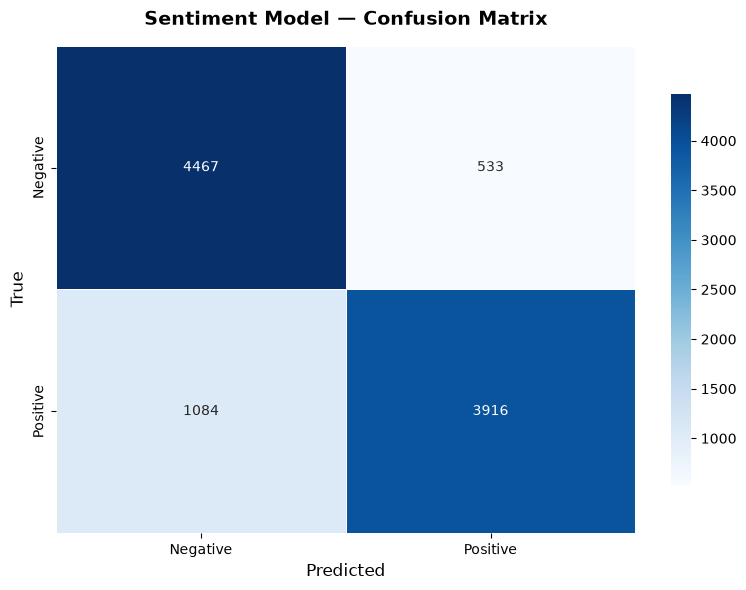

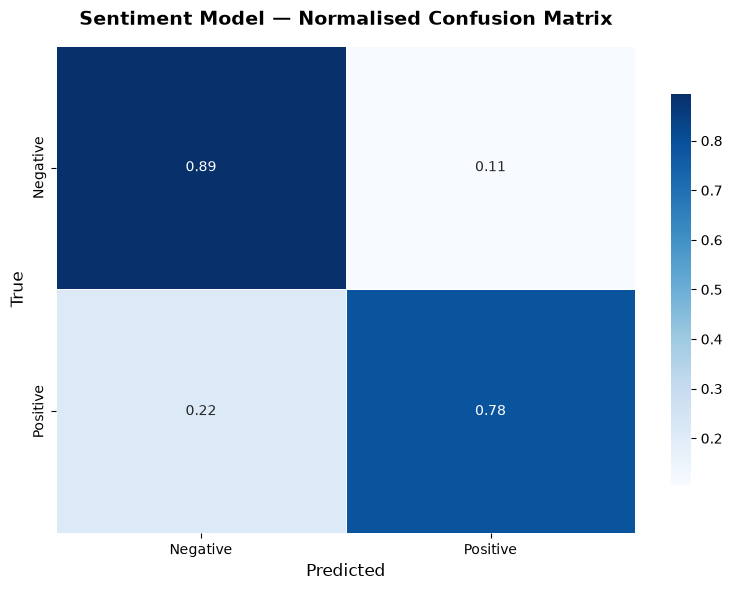

In [4]:
probs   = model.predict(X_test, verbose=0)
y_pred  = predictions_from_probs(probs)

fig = plot_confusion_matrix(
    y_test, y_pred, display_names,
    title='Sentiment Model — Confusion Matrix'
)
fig.savefig('sentiment_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# Normalised version
fig2 = plot_confusion_matrix(
    y_test, y_pred, display_names,
    title='Sentiment Model — Normalised Confusion Matrix', normalise=True
)
fig2.savefig('sentiment_confusion_matrix_norm.png', dpi=120, bbox_inches='tight')
plt.show()

## 4 · Per-Class Confidence Distribution

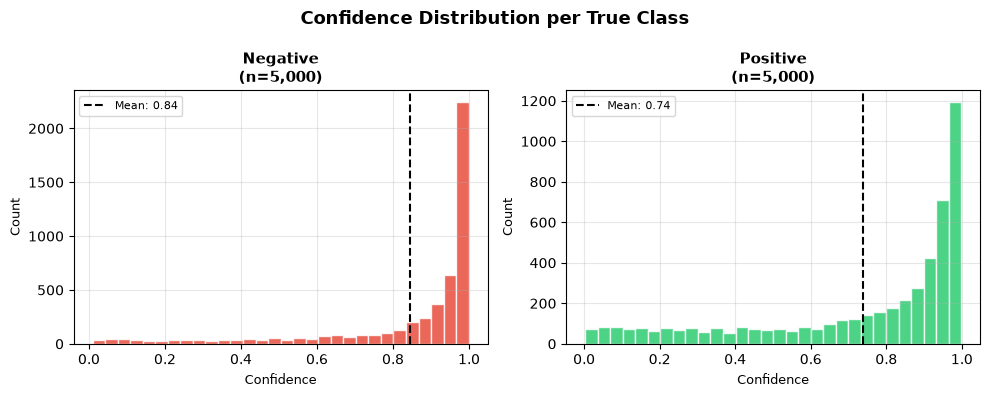

In [5]:
fig, axes = plt.subplots(1, len(display_names), figsize=(5 * len(display_names), 4))
if len(display_names) == 1:
    axes = [axes]

colors_map = {'Negative': '#E74C3C', 'Neutral': '#F39C12', 'Positive': '#2ECC71'}

for i, (name, ax) in enumerate(zip(display_names, axes)):
    # Filter predictions where this class is the true label
    mask       = y_test == i
    conf_vals  = probs[mask, i]
    color      = colors_map.get(name, '#3498DB')
    ax.hist(conf_vals, bins=30, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{name}\n(n={mask.sum():,})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Confidence', fontsize=9)
    ax.set_ylabel('Count',      fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axvline(np.mean(conf_vals), color='black', linestyle='--',
               label=f'Mean: {np.mean(conf_vals):.2f}')
    ax.legend(fontsize=8)

plt.suptitle('Confidence Distribution per True Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confidence_distributions.png', dpi=120)
plt.show()

## 5 · Emotion Detection Demo

In [6]:
emotion_samples = [
    ('joy',          'I am so happy and thrilled about this amazing news!'),
    ('sadness',      'I feel heartbroken and devastated after what happened.'),
    ('anger',        'I am absolutely furious and outraged at this injustice!'),
    ('fear',         'I am terrified and extremely anxious about the surgery.'),
    ('surprise',     'I was completely shocked and astonished by the unexpected outcome.'),
    ('anticipation', 'I am so eager and looking forward to the upcoming trip!'),
    ('trust',        'I fully trust and believe in the reliability of this team.'),
    ('neutral',      'The report was submitted on Monday at 10 am.'),
]

print('Emotion Detection Demo')
print('=' * 70)
for expected, text in emotion_samples:
    result   = full_analysis(text)
    emoji    = get_emotion_emoji(result['dominant_emotion'])
    color_ok = '✓' if result['dominant_emotion'] == expected else '~'
    print(f'{color_ok} Expected: {expected:<14} Detected: {result["dominant_emotion"]:<14} {emoji}')
    print(f'  Sentiment: {result["label"]}  ({result["confidence"]*100:.1f}%)')
    print(f'  Text: {text[:70]}...' if len(text) > 70 else f'  Text: {text}')
    print()

Emotion Detection Demo
✓ Expected: joy            Detected: joy            😊
  Sentiment: Neutral  (85.9%)
  Text: I am so happy and thrilled about this amazing news!

✓ Expected: sadness        Detected: sadness        😢
  Sentiment: Neutral  (65.0%)
  Text: I feel heartbroken and devastated after what happened.

✓ Expected: anger          Detected: anger          😠
  Sentiment: Neutral  (64.2%)
  Text: I am absolutely furious and outraged at this injustice!

✓ Expected: fear           Detected: fear           😨
  Sentiment: Negative  (52.9%)
  Text: I am terrified and extremely anxious about the surgery.

✓ Expected: surprise       Detected: surprise       😲
  Sentiment: Neutral  (93.1%)
  Text: I was completely shocked and astonished by the unexpected outcome.

✓ Expected: anticipation   Detected: anticipation   🌟
  Sentiment: Negative  (58.1%)
  Text: I am so eager and looking forward to the upcoming trip!

✓ Expected: trust          Detected: trust          🤝
  Sentiment: Neutral 

## 6 · Interactive Single Sample Prediction

In [7]:
# Change this text and re-run to test the model
TEST_TEXT = 'The service was terrible and the food was cold. Very disappointed.'

result = full_analysis(TEST_TEXT)

print('─' * 60)
print(f'Input     : {TEST_TEXT}')
print('─' * 60)
print(f'Sentiment : {result["label"]}  (confidence: {result["confidence"]*100:.1f}%)')
print(f'Emotion   : {result["description"]}')
print('\nClass Probabilities:')
for label, pct in result['probabilities'].items():
    bar = '█' * int(pct / 2) + '░' * (50 - int(pct / 2))
    print(f'  {label:<10} [{bar}] {pct:.1f}%')

────────────────────────────────────────────────────────────
Input     : The service was terrible and the food was cold. Very disappointed.
────────────────────────────────────────────────────────────
Sentiment : Negative  (confidence: 97.7%)
Emotion   : 😢 The text expresses sadness or grief.

Class Probabilities:
  Negative   [████████████████████████████████████████████████░░] 97.7%
  Neutral    [█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 2.3%


## Evaluation Complete